# Импорты библиотек

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Построение эмпирической функции распределения с доверительным интервалом

In [53]:
def empiric_distribution_function(data: np.ndarray, x: float, alpha: float = 0.05) -> tuple[int, tuple[float, float]]:
    data = np.sort(data)
    n = len(data)
    
    value = np.where(data <= x)[0].size / n

    epsilon = np.sqrt(np.log(2 / alpha) / (2 * n))
    
    lower_bound = max(0, value - epsilon)
    upper_bound = min(1, value + epsilon)
    
    return value, (lower_bound, upper_bound)

## Выборки

In [54]:
random_state = 18
data = {
    "uniform": {100: {}, 1000: {}},
    "bernoulli": {100: {}, 1000: {}},
    "binom": {100: {}, 1000: {}},
    "norm": {100: {}, 1000: {}}
}

data["uniform"][100]["X"] = stats.uniform.rvs(loc=-1, scale=5, size=100, random_state=random_state)
data["uniform"][1000]["X"] = stats.uniform.rvs(loc=-1, scale=5, size=1000, random_state=random_state)

data["bernoulli"][100]["X"] = stats.bernoulli.rvs(p=0.25, size=100, random_state=random_state)
data["bernoulli"][1000]["X"] = stats.bernoulli.rvs(p=0.25, size=1000, random_state=random_state)

data["binom"][100]["X"] = stats.binom.rvs(p=0.25, n=17, size=100, random_state=random_state)
data["binom"][1000]["X"] = stats.binom.rvs(p=0.25, n=17, size=1000, random_state=random_state)

data["norm"][100]["X"] = stats.norm.rvs(loc=15, scale=5, size=100, random_state=random_state)
data["norm"][1000]["X"] = stats.norm.rvs(loc=15, scale=5, size=1000, random_state=random_state)

# 2. Сравнение истинной функции распределения и эмпирической функций распределения

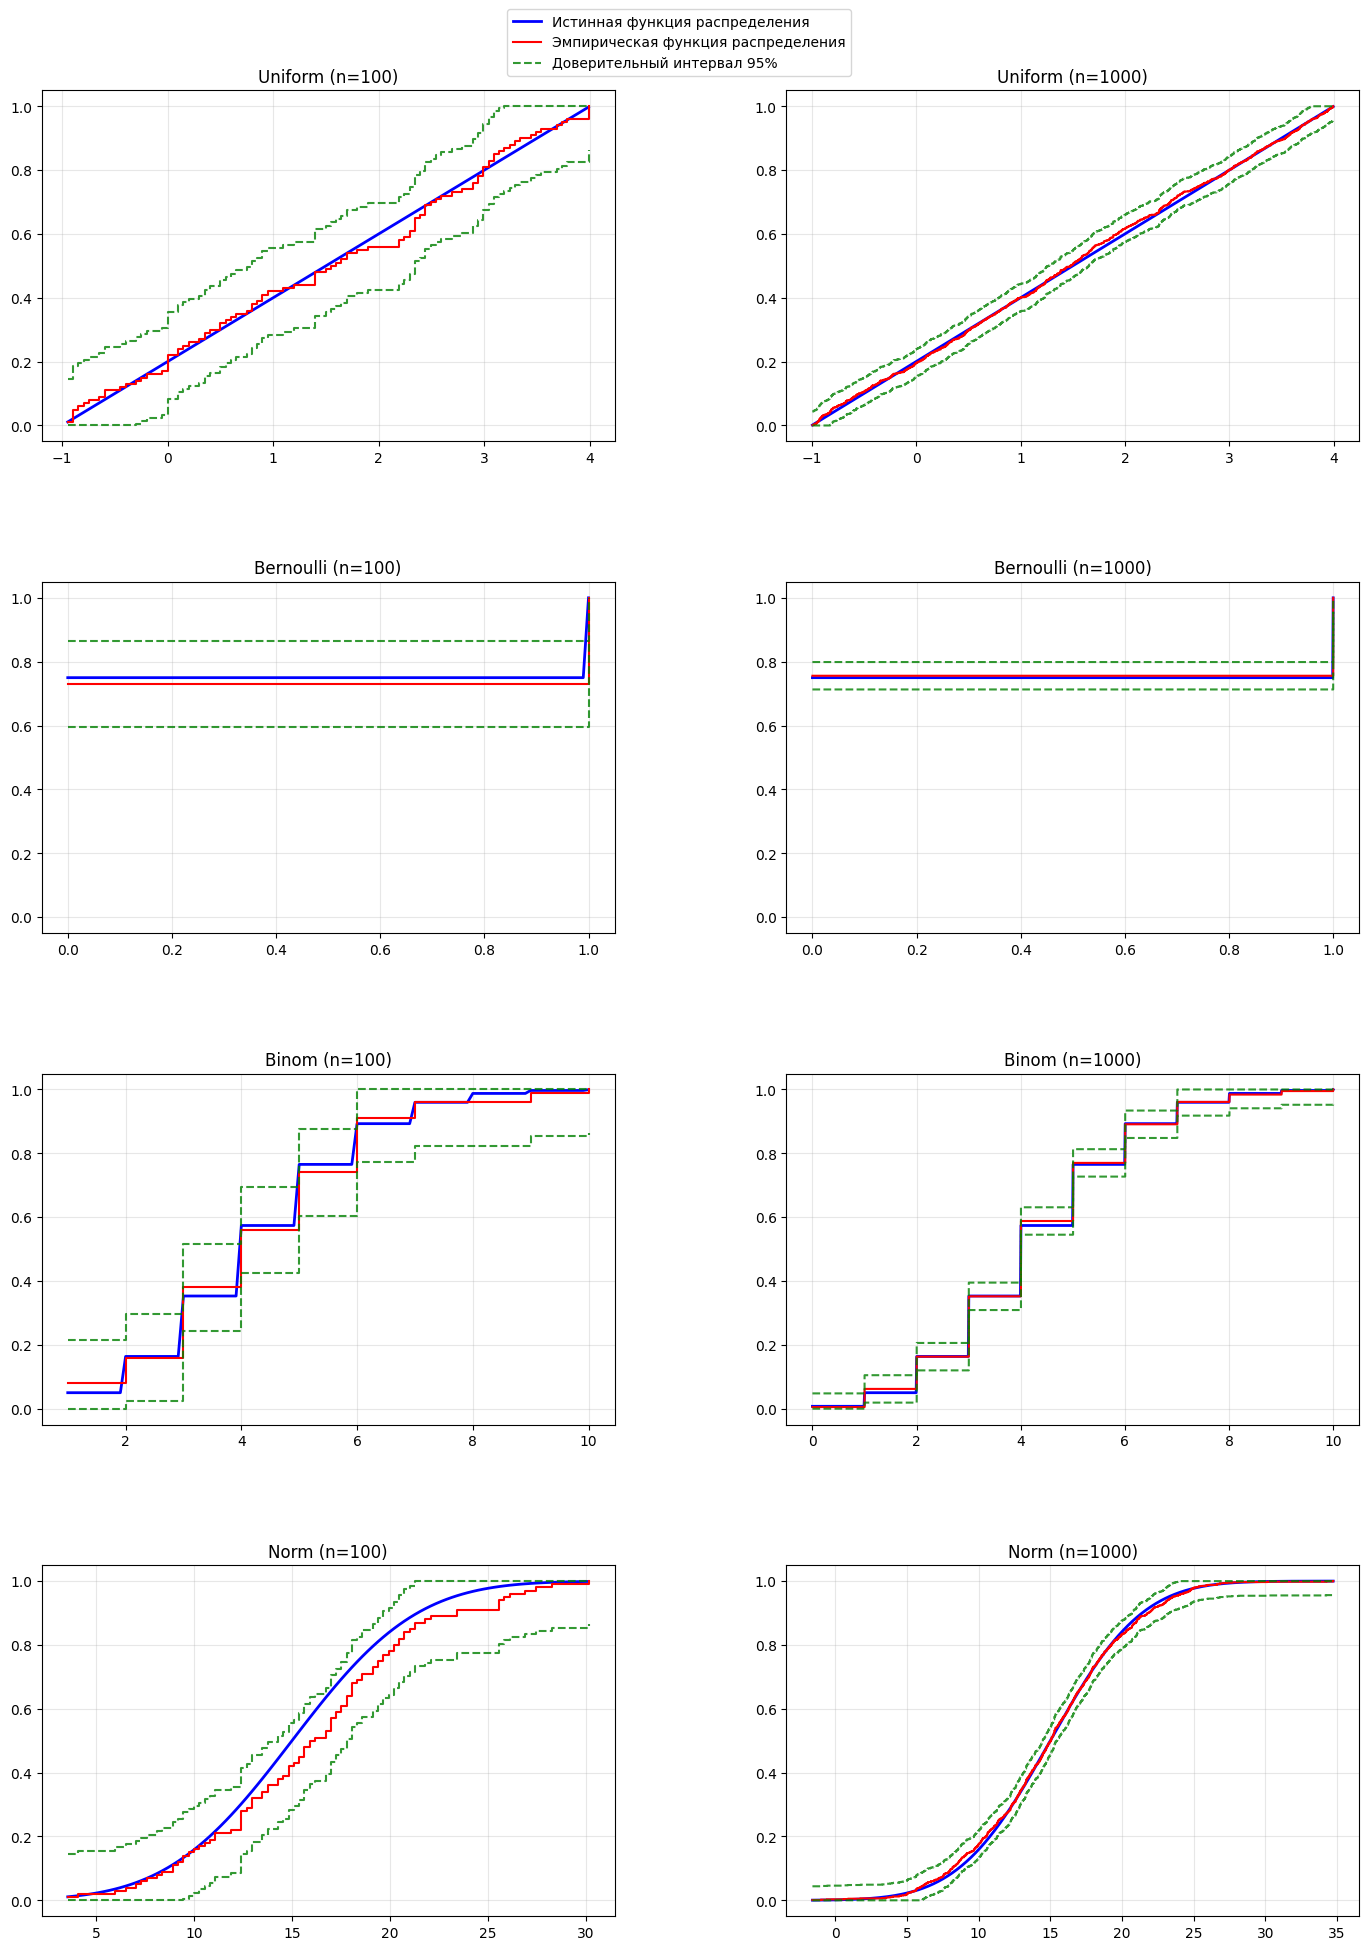

In [55]:
def plot_all_distribution_functions(data: dict[str, dict[int, dict]]) -> None:
    fig, axes = plt.subplots(4, 2, figsize=(17, 22))
    fig.subplots_adjust(hspace=0.4, wspace=0.3)
    
    distribution_names = ["uniform", "bernoulli", "binom", "norm"]
    sizes = [100, 1000]
    
    for i, distribution in enumerate(distribution_names):
        for j, size in enumerate(sizes):
            ax = axes[i, j]
            sample = data[distribution][size]["X"]
            sample_sorted = np.sort(sample)
            
            x_min, x_max = sample_sorted[0], sample_sorted[-1]
            x_range = np.linspace(x_min, x_max, size)
            
            if distribution == "uniform":
                true_cdf = stats.uniform.cdf(x_range, loc=-1, scale=5)
            elif distribution == "bernoulli":
                true_cdf = stats.bernoulli.cdf(x_range, p=0.25)
            elif distribution == "binom":
                true_cdf = stats.binom.cdf(x_range, p=0.25, n=17)
            elif distribution == "norm":
                true_cdf = stats.norm.cdf(x_range, loc=15, scale=5)
            
            l1, = ax.plot(x_range, true_cdf, color='blue', label='Истинная функция распределения', linewidth=2)
            
            values = []
            lower_bounds = []
            upper_bounds = []
            
            for x in x_range:
                val, (low, upp) = empiric_distribution_function(sample, x)
                values.append(val)
                lower_bounds.append(low)
                upper_bounds.append(upp)
            
            l2, = ax.step(x_range, values, color='red', label='Эмпирическая функция распределения', where='post')
            
            l3, =ax.step(x_range, lower_bounds, color='green', linestyle='--', label='Доверительный интервал 95%', alpha=0.8, where='post')
            ax.step(x_range, upper_bounds, color='green', linestyle='--', alpha=0.8, where='post')
            
            ax.set_title(f"{distribution.capitalize()} (n={size})")
            ax.set_ylim(-0.05, 1.05)
            ax.grid(True, alpha=0.3)
            if i == 0 and j == 0:
                lines = [l1, l2, l3]
                labels = [l.get_label() for l in lines]

    fig.subplots_adjust(hspace=0.4, wspace=0.3, top=0.94)
    fig.legend(lines, labels, loc='upper center', ncol=1, frameon=True, bbox_to_anchor=(0.5, 0.98))
    plt.show()

plot_all_distribution_functions(data)

# 3. Сравнение истинной функции распределения и эмпирической функции распределения из scipy.stats

/tmp/ipykernel_127349/2383896147.py:30: RuntimeWarning: The confidence interval is undefined at some observations. This is a feature of the mathematical formula used, not an error in its implementation.
  continued_interval = ecdf_result.cdf.confidence_interval(confidence_level=0.95)


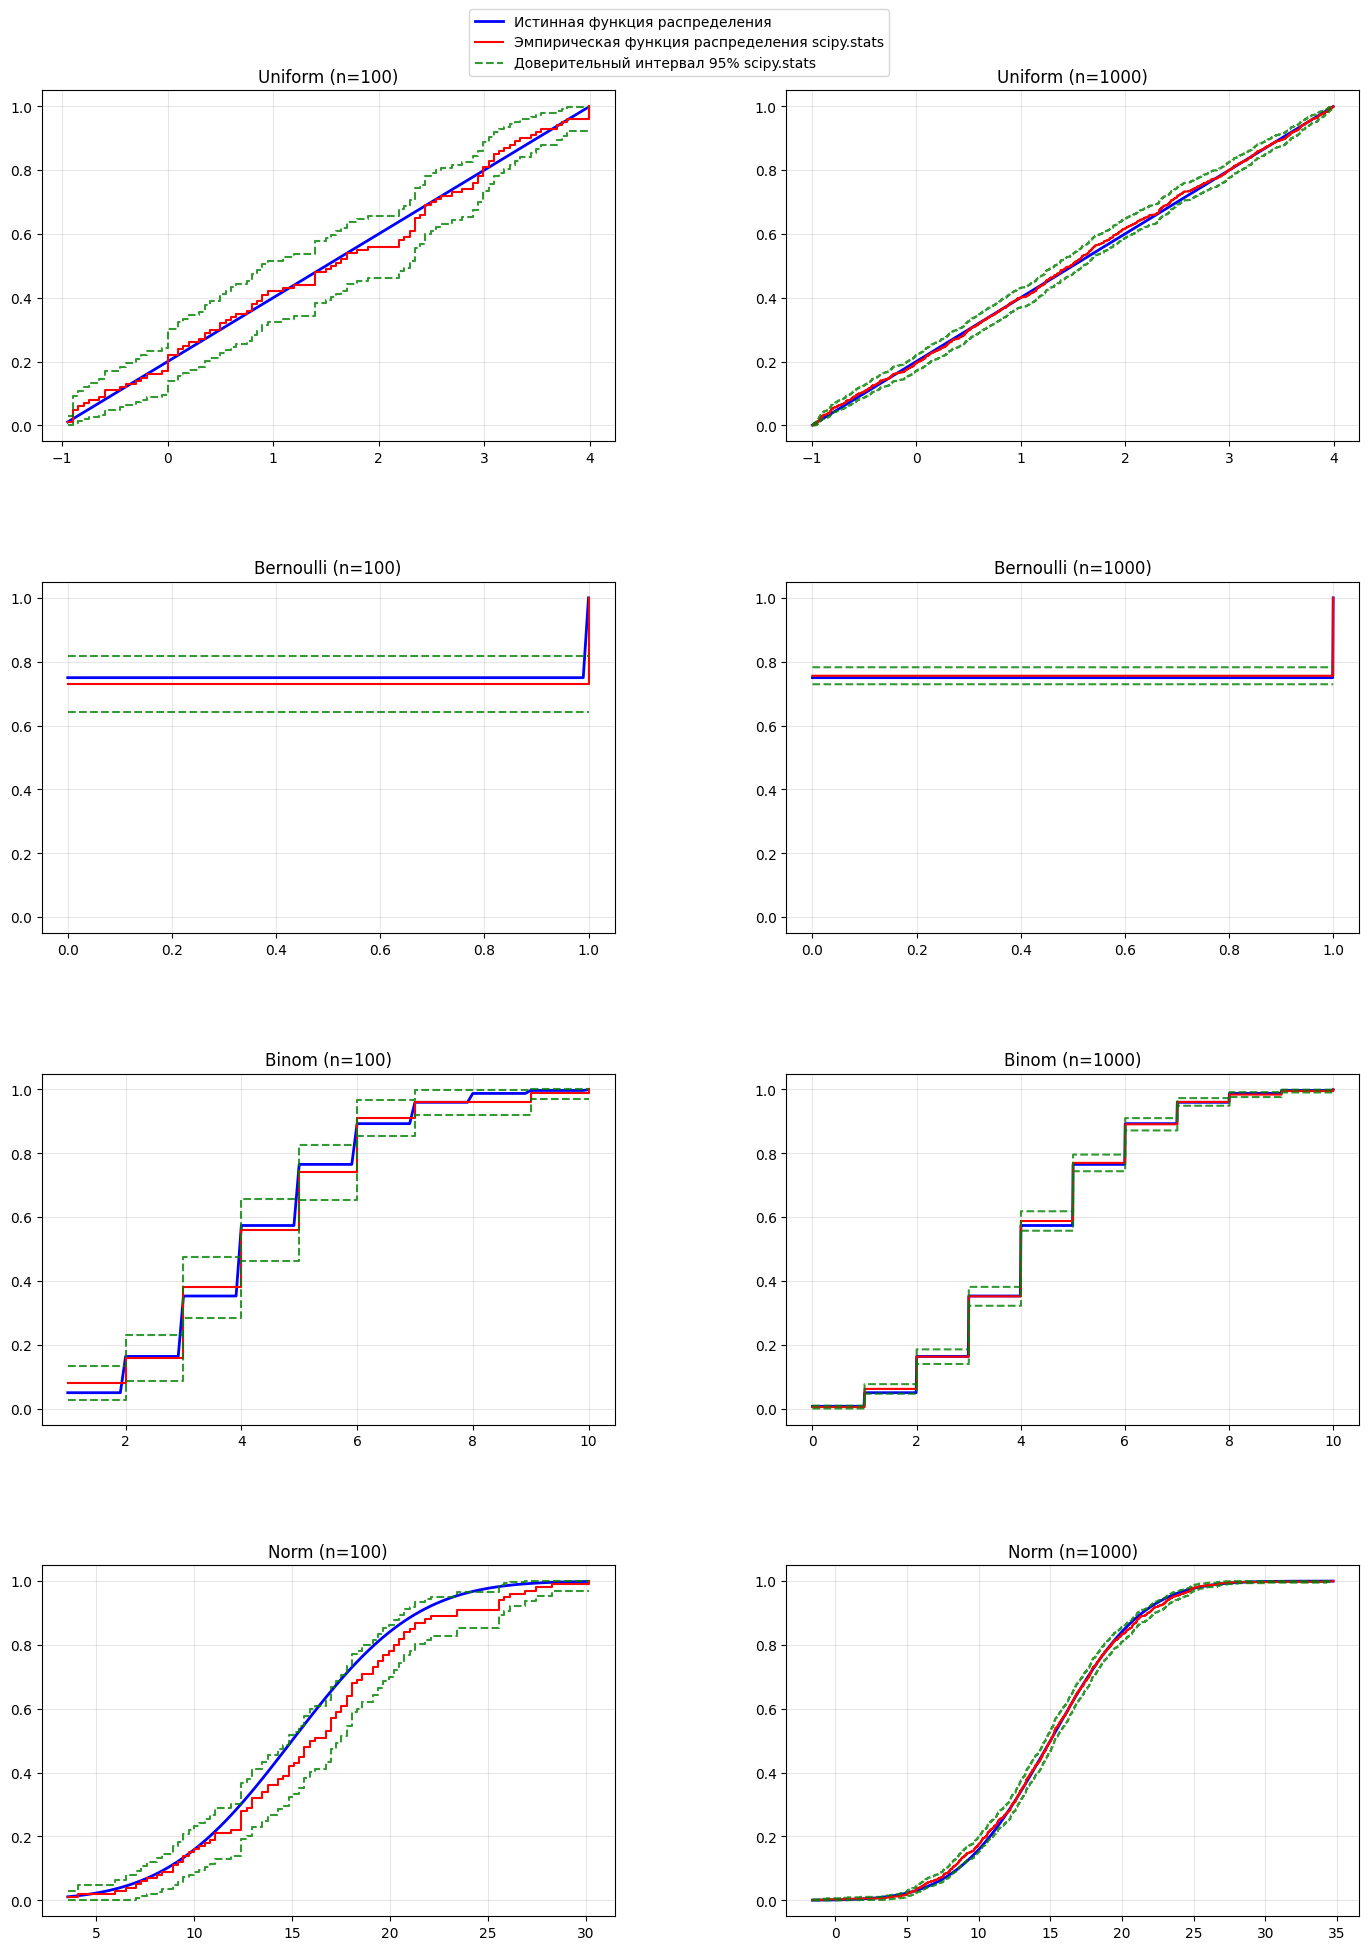

In [56]:
def plot_all_distribution_functions_scipy(data: dict[str, dict[int, dict]]) -> None:
    fig, axes = plt.subplots(4, 2, figsize=(17, 22))
    fig.subplots_adjust(hspace=0.4, wspace=0.3)
    
    distribution_names = ["uniform", "bernoulli", "binom", "norm"]
    sizes = [100, 1000]
    
    for i, distribution in enumerate(distribution_names):
        for j, size in enumerate(sizes):
            ax = axes[i, j]
            sample = data[distribution][size]["X"]
            sample_sorted = np.sort(sample)
            
            x_min, x_max = sample_sorted[0], sample_sorted[-1]
            x_range = np.linspace(x_min, x_max, size)
            
            if distribution == "uniform":
                true_cdf = stats.uniform.cdf(x_range, loc=-1, scale=5)
            elif distribution == "bernoulli":
                true_cdf = stats.bernoulli.cdf(x_range, p=0.25)
            elif distribution == "binom":
                true_cdf = stats.binom.cdf(x_range, p=0.25, n=17)
            elif distribution == "norm":
                true_cdf = stats.norm.cdf(x_range, loc=15, scale=5)
            
            l1, = ax.plot(x_range, true_cdf, color='blue', label='Истинная функция распределения', linewidth=2)
            
            ecdf_result = stats.ecdf(sample)
            values = ecdf_result.cdf.evaluate(x_range)
            continued_interval = ecdf_result.cdf.confidence_interval(confidence_level=0.95)
            
            l2, = ax.step(x_range, values, color='red', label='Эмпирическая функция распределения scipy.stats', where='post')
            
            l3, = ax.step(x_range, continued_interval.low.evaluate(x_range), color='green', linestyle='--', label='Доверительный интервал 95% scipy.stats', alpha=0.8, where='post')
            ax.step(x_range, continued_interval.high.evaluate(x_range), color='green', linestyle='--', alpha=0.8, where='post')
            
            ax.set_title(f"{distribution.capitalize()} (n={size})")
            ax.set_ylim(-0.05, 1.05)
            ax.grid(True, alpha=0.3)
            if i == 0 and j == 0:
                lines = [l1, l2, l3]
                labels = [l.get_label() for l in lines]

    fig.subplots_adjust(hspace=0.4, wspace=0.3, top=0.94)
    fig.legend(lines, labels, loc='upper center', ncol=1, frameon=True, bbox_to_anchor=(0.5, 0.98))
    plt.show()

plot_all_distribution_functions_scipy(data)